In [ ]:
!pip install scikit-surprise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

**LOAD DATASET**

In [ ]:
ratings = pd.read_csv('/content/drive/MyDrive/Sistem Rekomendasi/ratings.csv')
movies = pd.read_csv('/content/drive/MyDrive/Sistem Rekomendasi/movies.csv')
print(ratings.head())
print(movies.head())

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


**VISUALISASI DISTRIBUSI RATING**

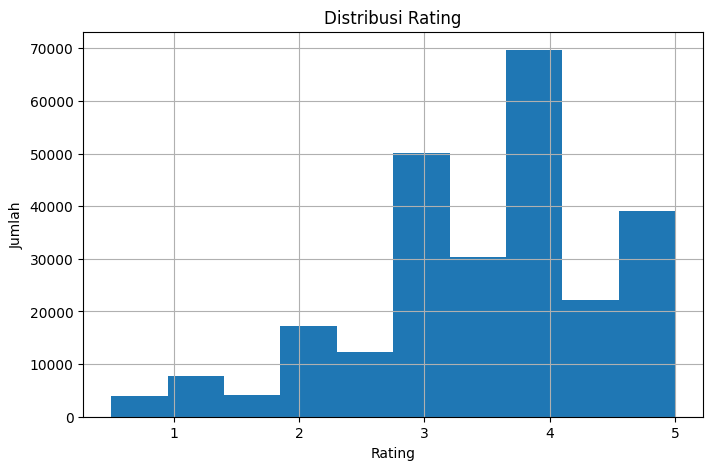

In [ ]:
plt.figure(figsize=(8,5))
ratings['rating'].hist(bins=10)
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.title('Distribusi Rating')
plt.show()

**FILM PALING POPULER**

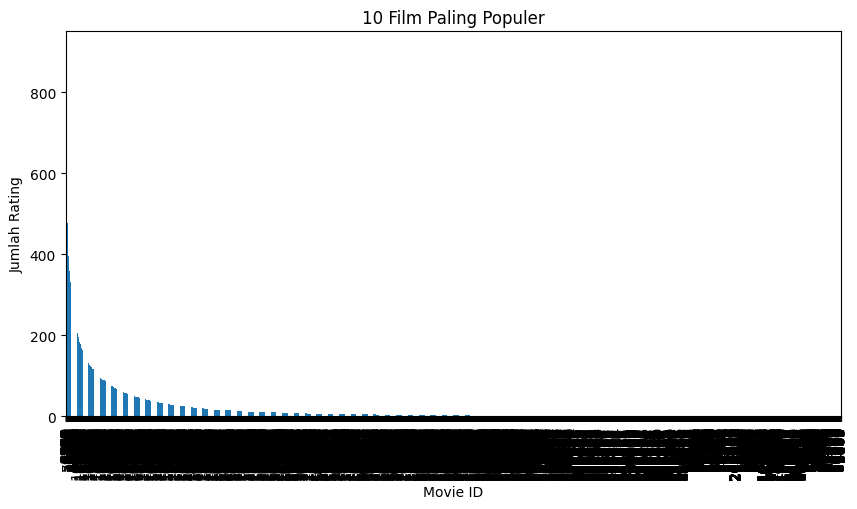

In [ ]:
popular_movies = ratings.groupby('movieId').size().sort_values(ascending=False)
plt.figure(figsize=(10,5))
popular_movies.plot(kind='bar')
plt.xlabel('Movie ID')
plt.ylabel('Jumlah Rating')
plt.title('10 Film Paling Populer')
plt.show()

**MEMBUAT USER-ITEM MATRIX**

In [ ]:
user_movie_matrix = ratings.pivot_table(
index='userId',
columns='movieId',
values='rating'
).fillna(0)
user_movie_matrix.head()


movieId,1,2,3,4,5,6,7,8,9,10,...,205967,206272,206293,206499,206523,206805,206861,207309,208002,208793
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**COSINE SIMILARITY**

In [ ]:
similarity = cosine_similarity(user_movie_matrix)
similarity_df = pd.DataFrame(similarity)
similarity_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818
0,1.000000,0.040863,0.061306,0.040815,0.015609,0.000000,0.093852,0.021359,0.022860,0.026149,...,0.000000,0.032503,0.058512,0.045504,0.040398,0.034279,0.079646,0.039403,0.000000,0.000000
1,0.040863,1.000000,0.179009,0.197496,0.158202,0.129720,0.064954,0.176880,0.128820,0.156814,...,0.060128,0.134488,0.155751,0.090542,0.216915,0.247093,0.201028,0.088202,0.026935,0.000000
2,0.061306,0.179009,1.000000,0.357750,0.061448,0.115148,0.031427,0.081003,0.061602,0.132361,...,0.051567,0.137691,0.320807,0.131941,0.135547,0.147177,0.331350,0.062318,0.006683,0.083322
3,0.040815,0.197496,0.357750,1.000000,0.065825,0.072365,0.015566,0.088927,0.066428,0.083821,...,0.038230,0.082280,0.346221,0.148048,0.097028,0.212523,0.314150,0.080324,0.000000,0.071138
4,0.015609,0.158202,0.061448,0.065825,1.000000,0.114936,0.202348,0.307769,0.216435,0.269897,...,0.241303,0.168322,0.041310,0.000000,0.306304,0.144816,0.120777,0.099034,0.042441,0.000000


**HEATMAP SIMILARITY**

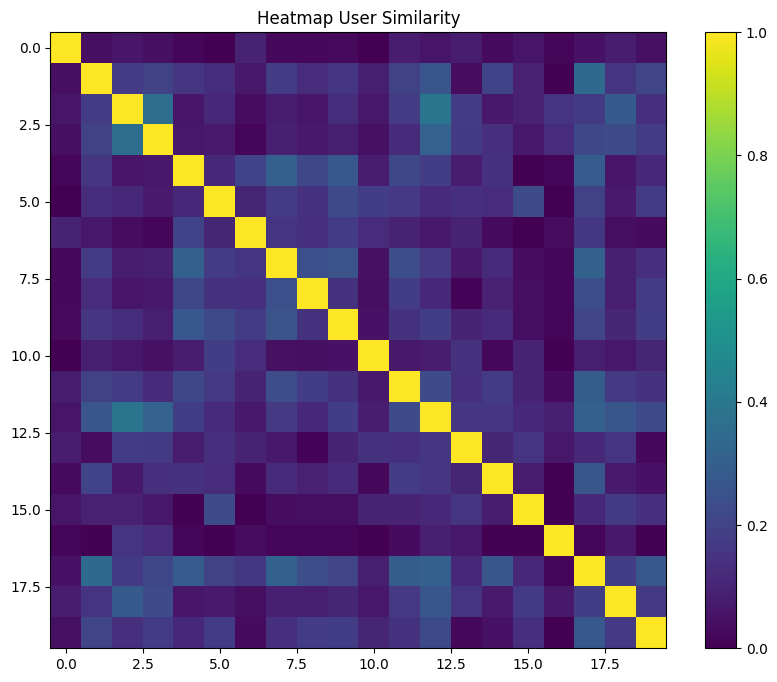

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(similarity_df.iloc[:20,:20])
plt.colorbar()
plt.title('Heatmap User Similarity')
plt.show()

**MATRIX FACTORIZATIONDENGAN SVD**

In [ ]:
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(
ratings[['userId', 'movieId', 'rating']],
reader
)
trainset, testset = train_test_split(
data,
test_size=0.2,
random_state=42
)
model = SVD()
model.fit(trainset)

**EVALUASI MODEL**

In [ ]:
predictions = model.test(testset)
rmse(predictions)

RMSE: 0.8698


np.float64(0.8697875671876729)

**PREDIKSI RATING**

In [ ]:
user_id = 1
movie_id = 50
pred = model.predict(user_id, movie_id)
print("Predicted Rating:", pred.est)

Predicted Rating: 4.52046874523553


**TOP RECOMENDATION**

In [ ]:
movie_ids = ratings['movieId'].unique()
predictions = []
for movie_id in movie_ids:
    pred = model.predict(1, movie_id)
    predictions.append((movie_id, pred.est))
predictions.sort(key=lambda x: x[1], reverse=True)
top_recommendations = predictions[:10]
movie_names = []
movie_scores = []
for movie_id, rating in top_recommendations:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    movie_names.append(title)
    movie_scores.append(rating)
    print(title, ":", rating)

Rosencrantz and Guildenstern Are Dead (1990) : 4.707376050531431
Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) : 4.635834898254182
In the Mood For Love (Fa yeung nin wa) (2000) : 4.618522984011009
Boot, Das (Boat, The) (1981) : 4.555032761259813
Fight Club (1999) : 4.547549012559925
Wallace & Gromit: The Wrong Trousers (1993) : 4.529663003023506
Monty Python and the Holy Grail (1975) : 4.52627057705447
Usual Suspects, The (1995) : 4.52046874523553
Star Wars: Episode IV - A New Hope (1977) : 4.511114152176174
Lives of Others, The (Das leben der Anderen) (2006) : 4.490074795996809


**VISUALISASI TOP RECOMENDATION**

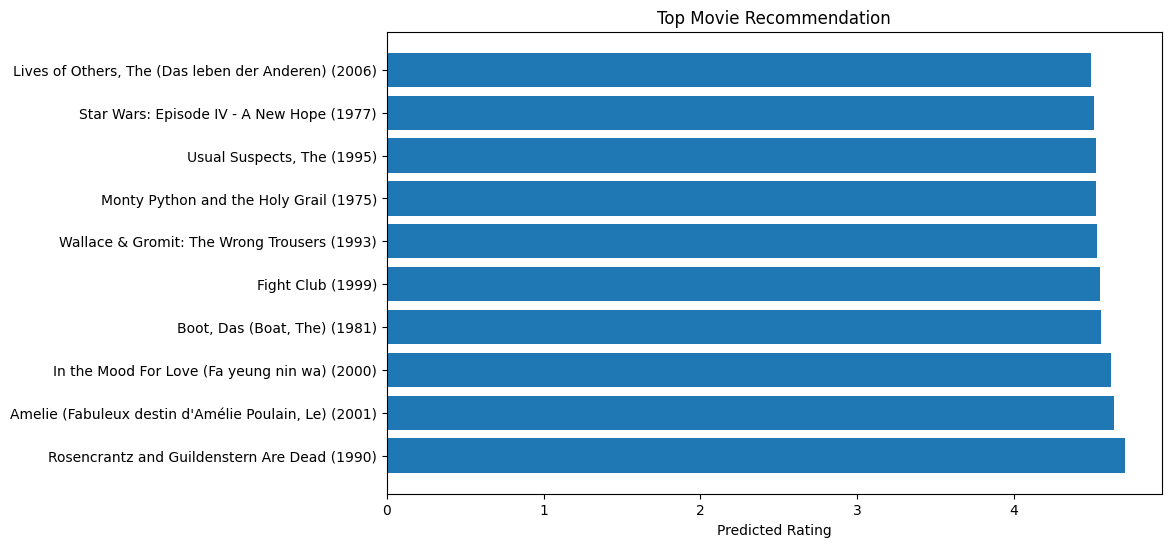

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(movie_names, movie_scores)
plt.xlabel('Predicted Rating')
plt.title('Top Movie Recommendation')
plt.show()

**PCA VISUALIZATION**

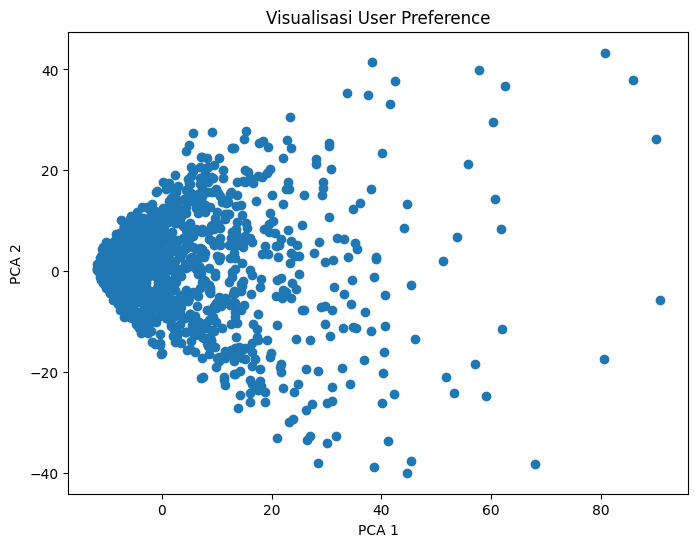

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(user_movie_matrix)
plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi User Preference')
plt.show()